# Sensitivity and Fragility Analysis

In [14]:
import pandas as pd
import os
from codelib.file_management.dynamic_file_pathing import get_root
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import seaborn as sns

## Load data and build dictionaries

In [15]:
root = get_root()

base_path = os.path.join(root, "Risk Metrics", "Stress_testing", "base.csv")
base_df   = pd.read_csv(base_path, header=0, index_col=0)

sources = {
    'Contribution':  os.path.join(root, "Risk Metrics", "Stress_testing", "Contribution"),
    'Expected Return': os.path.join(root, "Risk Metrics", "Stress_testing", "Expected Return"),
    'Wealth': os.path.join(root, "Risk Metrics", "Stress_testing", "Wealth"),
    'Volatility': os.path.join(root, "Risk Metrics", "Stress_testing", "Volatility"),
    'Inflation': os.path.join(root, "Risk Metrics", "Stress_testing", "Inflation"),
}

scenarios = {
    "-10%": "10m.csv", "-25%": "25m.csv", "-50%": "50m.csv",
    "+10%": "10p.csv", "+25%": "25p.csv", "+50%": "50p.csv"
}

## Calculate success rates

In [16]:
base_SR = base_df.groupby(level=0)['Successes'].mean() / 1000

In [17]:
base_SR

Goal
A    0.666
B    0.636
C    0.693
D    0.000
Name: Successes, dtype: float64

In [18]:
success_rates = {}
for src_name, folder in sources.items():
    success_rates[src_name] = {}
    for scen_name, fname in scenarios.items():
        df   = pd.read_csv(os.path.join(folder, fname), header=0, index_col=0)
        # aggregate replicates per goal
        sr   = df.groupby(level=0)['Successes'].mean() / 50
        success_rates[src_name][scen_name] = sr

In [19]:
print("=== Base Success Rates (%) ===")
print((base_SR).round(2))

=== Base Success Rates (%) ===
Goal
A    0.67
B    0.64
C    0.69
D    0.00
Name: Successes, dtype: float64


In [20]:
for src, scen_dict in success_rates.items():
    df_rates = pd.DataFrame(scen_dict)     # convert fraction → %
    df_rates = df_rates.round(2)                 # e.g. 34.56
    print(f"\n=== {src} Success Rates (%) ===")
    print(df_rates)


=== Contribution Success Rates (%) ===
      -10%  -25%  -50%  +10%  +25%  +50%
Goal                                    
A     0.40  0.18  0.02  0.84  1.00  1.00
B     0.60  0.50  0.36  0.60  0.62  0.70
C     0.68  0.76  0.76  0.68  0.60  0.48
D     0.00  0.00  0.00  0.00  0.00  0.00

=== Expected Return Success Rates (%) ===
      -10%  -25%  -50%  +10%  +25%  +50%
Goal                                    
A     0.64  0.64  0.56  0.66  0.56  0.60
B     0.64  0.68  0.76  0.62  0.64  0.68
C     0.72  0.60  0.60  0.66  0.56  0.60
D     0.00  0.00  0.00  0.00  0.00  0.00

=== Wealth Success Rates (%) ===
      -10%  -25%  -50%  +10%  +25%  +50%
Goal                                    
A     0.64  0.68  0.66  0.58  0.68  0.70
B     0.62  0.60  0.64  0.56  0.58  0.68
C     0.68  0.78  0.76  0.60  0.60  0.56
D     0.00  0.00  0.00  0.00  0.00  0.00

=== Volatility Success Rates (%) ===
      -10%  -25%  -50%  +10%  +25%  +50%
Goal                                    
A     0.56  0.68  0.64  0

## First order stress test

In [21]:
stress_diff = {}
for src, scen_dict in success_rates.items():
    stress_diff[src] = {}
    for scen, sr in scen_dict.items():
        # now sr and base_SR both have unique index A,B,C,D
        stress_diff[src][scen] = (sr - base_SR)   # in %-points

In [22]:
for src, diffs in stress_diff.items():
    df = pd.DataFrame(diffs).round(4)
    print(f"\n=== {src} (pp change vs base) ===")
    print(df)


=== Contribution (pp change vs base) ===
       -10%   -25%   -50%   +10%   +25%   +50%
Goal                                          
A    -0.266 -0.486 -0.646  0.174  0.334  0.334
B    -0.036 -0.136 -0.276 -0.036 -0.016  0.064
C    -0.013  0.067  0.067 -0.013 -0.093 -0.213
D     0.000  0.000  0.000  0.000  0.000  0.000

=== Expected Return (pp change vs base) ===
       -10%   -25%   -50%   +10%   +25%   +50%
Goal                                          
A    -0.026 -0.026 -0.106 -0.006 -0.106 -0.066
B     0.004  0.044  0.124 -0.016  0.004  0.044
C     0.027 -0.093 -0.093 -0.033 -0.133 -0.093
D     0.000  0.000  0.000  0.000  0.000  0.000

=== Wealth (pp change vs base) ===
       -10%   -25%   -50%   +10%   +25%   +50%
Goal                                          
A    -0.026  0.014 -0.006 -0.086  0.014  0.034
B    -0.016 -0.036  0.004 -0.076 -0.056  0.044
C    -0.013  0.087  0.067 -0.093 -0.093 -0.133
D     0.000  0.000  0.000  0.000  0.000  0.000

=== Volatility (pp change vs b

## Second order stress test

In [23]:
delta_pairs = [("-10%", "+10%"), ("-25%", "+25%"), ("-50%", "+50%")]

all_fragility = {}
for src, scen_dict in success_rates.items():
    all_fragility[src] = {}
    for neg, pos in delta_pairs:
        H = (scen_dict[neg] + scen_dict[pos]) / 2 - base_SR
        all_fragility[src][f"{neg}/{pos}"] = H



In [24]:
fragility_full_df = pd.DataFrame({
    f"{src} ({pair})": series
    for src, pairs in all_fragility.items()
    for pair, series in pairs.items()
}).round(4)

print(fragility_full_df)

      Contribution (-10%/+10%)  Contribution (-25%/+25%)  \
Goal                                                       
A                       -0.046                    -0.076   
B                       -0.036                    -0.076   
C                       -0.013                    -0.013   
D                        0.000                     0.000   

      Contribution (-50%/+50%)  Expected Return (-10%/+10%)  \
Goal                                                          
A                       -0.156                       -0.016   
B                       -0.106                       -0.006   
C                       -0.073                       -0.003   
D                        0.000                        0.000   

      Expected Return (-25%/+25%)  Expected Return (-50%/+50%)  \
Goal                                                             
A                          -0.066                       -0.086   
B                           0.024                        0.084

In [25]:
print(fragility_full_df.to_markdown(
    tablefmt="github",
    headers="keys",
    floatfmt=".2f"
))

| Goal   |   Contribution (-10%/+10%) |   Contribution (-25%/+25%) |   Contribution (-50%/+50%) |   Expected Return (-10%/+10%) |   Expected Return (-25%/+25%) |   Expected Return (-50%/+50%) |   Wealth (-10%/+10%) |   Wealth (-25%/+25%) |   Wealth (-50%/+50%) |   Volatility (-10%/+10%) |   Volatility (-25%/+25%) |   Volatility (-50%/+50%) |   Inflation (-10%/+10%) |   Inflation (-25%/+25%) |   Inflation (-50%/+50%) |
|--------|----------------------------|----------------------------|----------------------------|-------------------------------|-------------------------------|-------------------------------|----------------------|----------------------|----------------------|--------------------------|--------------------------|--------------------------|-------------------------|-------------------------|-------------------------|
| A      |                      -0.05 |                      -0.08 |                      -0.16 |                         -0.02 |                         -0

### Plot fragility scores

In [26]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


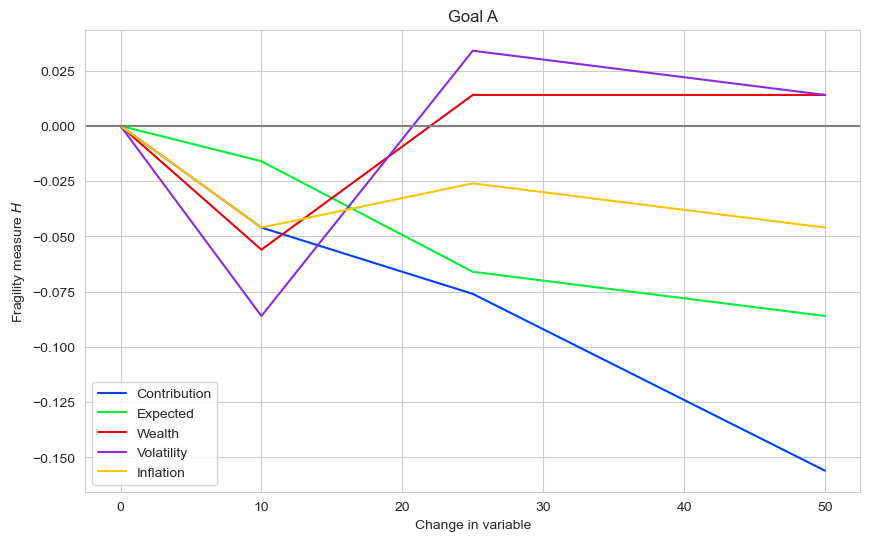

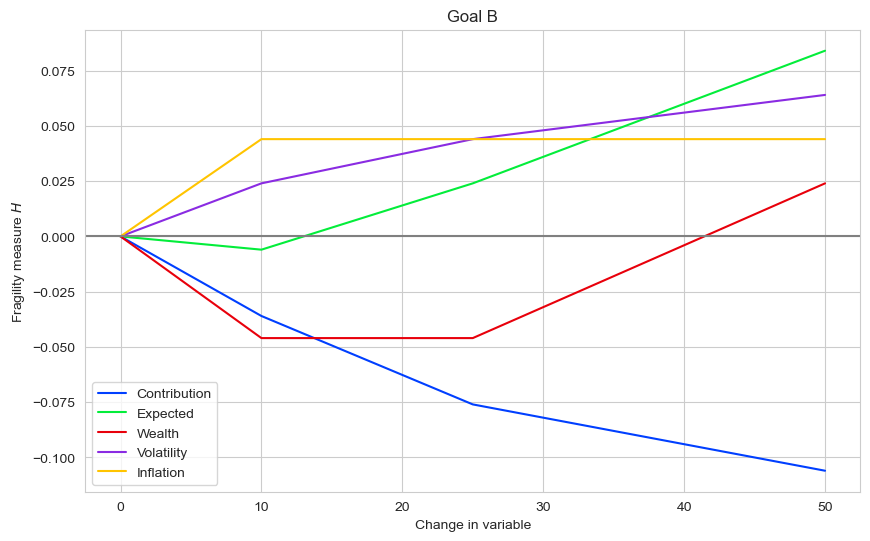

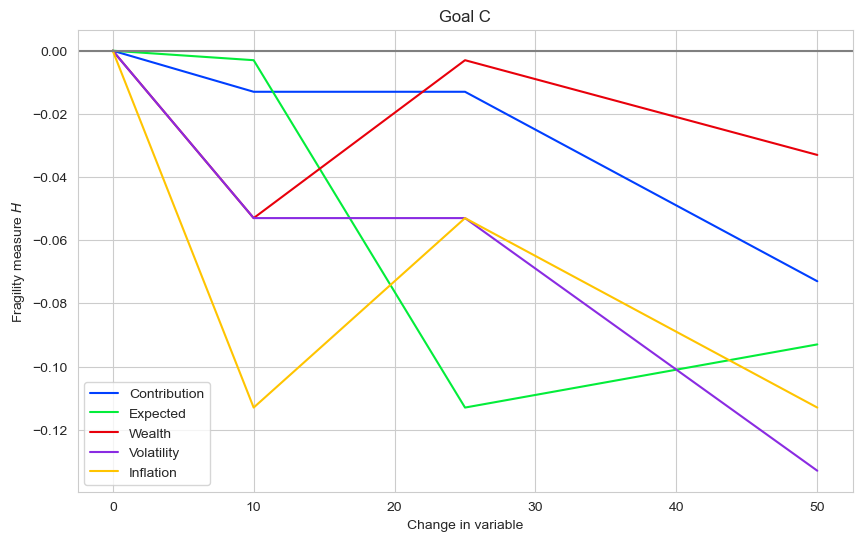

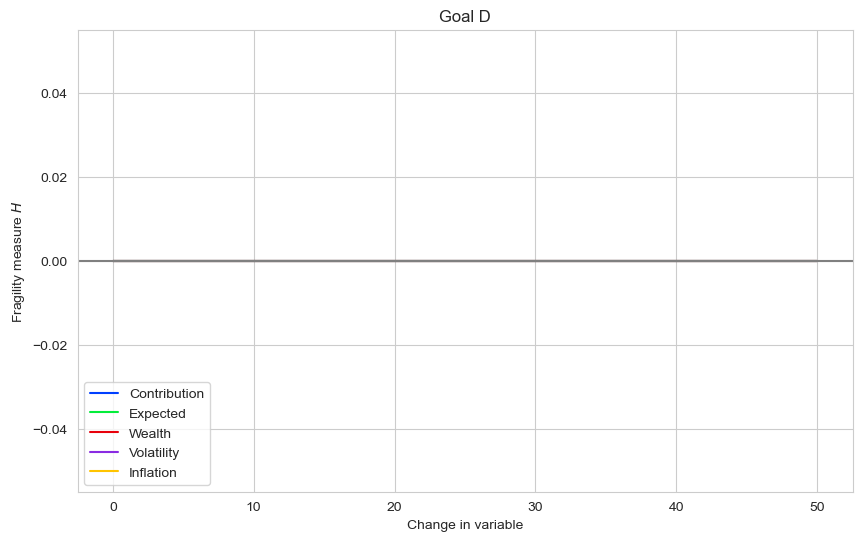

In [27]:
plt.style.use('seaborn-v0_8-bright')


column_info = [(col.split()[0], col[col.find('(')+1:col.find(')')])
               for col in fragility_full_df.columns]
# Map each variable to its list of (delta, column index)
var_to_entries = {}
for idx, (var, pair) in enumerate(column_info):
    delta = abs(float(pair.split('/')[0].strip('%+')))
    var_to_entries.setdefault(var, []).append((delta, idx))

# Generate a separate plot for each goal
for goal in fragility_full_df.index:
    plt.figure(figsize=(10, 6))
    for var, entries in var_to_entries.items():
        # Sort entries by delta magnitude
        entries_sorted = sorted(entries, key=lambda x: x[0])
        xs = [0] + [d for d, _ in entries_sorted]  # include Δ = 0
        ys = [0] + [fragility_full_df.iloc[fragility_full_df.index.get_loc(goal), idx]
                   for _, idx in entries_sorted]
        plt.plot(xs, ys, label=var)
    plt.axhline(0,color="gray")
    plt.xlabel(f'Change in variable')  # no explicit colours
    plt.ylabel('Fragility measure $H$')
    plt.title(f'Goal {goal}')
    plt.legend(loc='lower left')
    plt.show()

## Final Prints

### Base success rates

In [28]:
display(Markdown("## Base Success Rates"))
# if you want them as percentages:
base_pct = (base_SR * 100).round(2).to_frame("Success Rate %")
display(
    base_pct.style
           .format("{:.2f}%")
           .background_gradient(subset=["Success Rate %"])
)

## Base Success Rates

,Success Rate %
Goal,
A,66.60%
B,63.60%
C,69.30%
D,0.00%


### Scenario tables

In [29]:
for src, scen_dict in success_rates.items():
    display(Markdown(f"## {src} Success Rates"))
    df_rates = (pd.DataFrame(scen_dict) * 100).round(2)
    display(
        df_rates.style
                .format("{:.2f}%")
                .background_gradient(axis=1)
                .set_caption(f"{src}: Success Rates (%)")
    )

## Contribution Success Rates

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,40.00%,18.00%,2.00%,84.00%,100.00%,100.00%
B,60.00%,50.00%,36.00%,60.00%,62.00%,70.00%
C,68.00%,76.00%,76.00%,68.00%,60.00%,48.00%
D,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## Expected Return Success Rates

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,64.00%,64.00%,56.00%,66.00%,56.00%,60.00%
B,64.00%,68.00%,76.00%,62.00%,64.00%,68.00%
C,72.00%,60.00%,60.00%,66.00%,56.00%,60.00%
D,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## Wealth Success Rates

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,64.00%,68.00%,66.00%,58.00%,68.00%,70.00%
B,62.00%,60.00%,64.00%,56.00%,58.00%,68.00%
C,68.00%,78.00%,76.00%,60.00%,60.00%,56.00%
D,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## Volatility Success Rates

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,56.00%,68.00%,64.00%,60.00%,72.00%,72.00%
B,68.00%,64.00%,68.00%,64.00%,72.00%,72.00%
C,72.00%,64.00%,56.00%,56.00%,64.00%,56.00%
D,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## Inflation Success Rates

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,72.00%,88.00%,92.00%,52.00%,40.00%,32.00%
B,68.00%,72.00%,72.00%,68.00%,64.00%,64.00%
C,56.00%,64.00%,60.00%,60.00%,64.00%,56.00%
D,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


### First order stress test

In [30]:
for src, diffs in stress_diff.items():
    display(Markdown(f"## {src} Stress-Test Δ (pp)"))
    # stress_diff is in fractions, so *100 → pp
    df_pp = (pd.DataFrame(diffs) * 100).round(1)
    display(
        df_pp.style
             .format("{:.1f} pp")
             .background_gradient(axis=None)
             .set_caption(f"{src}: Δ vs Base (percentage points)")
    )



## Contribution Stress-Test Δ (pp)

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,-26.6 pp,-48.6 pp,-64.6 pp,17.4 pp,33.4 pp,33.4 pp
B,-3.6 pp,-13.6 pp,-27.6 pp,-3.6 pp,-1.6 pp,6.4 pp
C,-1.3 pp,6.7 pp,6.7 pp,-1.3 pp,-9.3 pp,-21.3 pp
D,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp


## Expected Return Stress-Test Δ (pp)

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,-2.6 pp,-2.6 pp,-10.6 pp,-0.6 pp,-10.6 pp,-6.6 pp
B,0.4 pp,4.4 pp,12.4 pp,-1.6 pp,0.4 pp,4.4 pp
C,2.7 pp,-9.3 pp,-9.3 pp,-3.3 pp,-13.3 pp,-9.3 pp
D,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp


## Wealth Stress-Test Δ (pp)

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,-2.6 pp,1.4 pp,-0.6 pp,-8.6 pp,1.4 pp,3.4 pp
B,-1.6 pp,-3.6 pp,0.4 pp,-7.6 pp,-5.6 pp,4.4 pp
C,-1.3 pp,8.7 pp,6.7 pp,-9.3 pp,-9.3 pp,-13.3 pp
D,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp


## Volatility Stress-Test Δ (pp)

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,-10.6 pp,1.4 pp,-2.6 pp,-6.6 pp,5.4 pp,5.4 pp
B,4.4 pp,0.4 pp,4.4 pp,0.4 pp,8.4 pp,8.4 pp
C,2.7 pp,-5.3 pp,-13.3 pp,-13.3 pp,-5.3 pp,-13.3 pp
D,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp


## Inflation Stress-Test Δ (pp)

,-10%,-25%,-50%,+10%,+25%,+50%
Goal,,,,,,
A,5.4 pp,21.4 pp,25.4 pp,-14.6 pp,-26.6 pp,-34.6 pp
B,4.4 pp,8.4 pp,8.4 pp,4.4 pp,0.4 pp,0.4 pp
C,-13.3 pp,-5.3 pp,-9.3 pp,-9.3 pp,-5.3 pp,-13.3 pp
D,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp,0.0 pp


### Second order stress test

In [31]:
display(Markdown("## Stress_testing Measures"))
frag_pct = (fragility_full_df * 100).round(2)
display(
    frag_pct.style
            .format("{:.2f}%")
            .background_gradient(axis=None)
            .set_caption("Stress_testing H (avg ±Δ scenarios)")
)

## Stress_testing Measures

,Contribution (-10%/+10%),Contribution (-25%/+25%),Contribution (-50%/+50%),Expected Return (-10%/+10%),Expected Return (-25%/+25%),Expected Return (-50%/+50%),Wealth (-10%/+10%),Wealth (-25%/+25%),Wealth (-50%/+50%),Volatility (-10%/+10%),Volatility (-25%/+25%),Volatility (-50%/+50%),Inflation (-10%/+10%),Inflation (-25%/+25%),Inflation (-50%/+50%)
Goal,,,,,,,,,,,,,,,
A,-4.60%,-7.60%,-15.60%,-1.60%,-6.60%,-8.60%,-5.60%,1.40%,1.40%,-8.60%,3.40%,1.40%,-4.60%,-2.60%,-4.60%
B,-3.60%,-7.60%,-10.60%,-0.60%,2.40%,8.40%,-4.60%,-4.60%,2.40%,2.40%,4.40%,6.40%,4.40%,4.40%,4.40%
C,-1.30%,-1.30%,-7.30%,-0.30%,-11.30%,-9.30%,-5.30%,-0.30%,-3.30%,-5.30%,-5.30%,-13.30%,-11.30%,-5.30%,-11.30%
D,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%


## To excel

In [32]:
# 1. Build your %-values as floats, rounded to 2 d.p.
df_rates = (pd.DataFrame(scen_dict) * 100).round(2)

# 2. Send a tab-separated version to the clipboard
df_rates.to_clipboard(sep='\t', index=True, header=True)